In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install yfinance pandas matplotlib seaborn

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
tickers = {
    "Brent_Close": "BZ=F",
    "Gold_Close": "GC=F",
    "USD_Index_Close": "DX-Y.NYB",
    "SP500_Close": "^GSPC",
    "VIX_Close": "^VIX"
}

start_date = "2014-01-01"
end_date = "2024-12-31"

all_data = {}

for col_name, ticker in tickers.items():
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

    df = df[["Close"]].copy()
    df.columns = [col_name]

    all_data[col_name] = df

# Merging all datasets on Date index
merged_df = pd.concat(all_data.values(), axis=1)

# Reset index to make Date a column
merged_df = merged_df.reset_index()

print(merged_df.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

        Date  Brent_Close   Gold_Close  USD_Index_Close  SP500_Close  \
0 2014-01-02   107.779999  1225.000000        80.629997  1831.979980   
1 2014-01-03   106.889999  1238.400024        80.790001  1831.369995   
2 2014-01-06   106.730003  1237.800049        80.650002  1826.770020   
3 2014-01-07   107.349998  1229.400024        80.830002  1837.880005   
4 2014-01-08   107.150002  1225.300049        81.040001  1837.489990   

   VIX_Close  
0      14.23  
1      13.76  
2      13.55  
3      12.92  
4      12.87  


In [25]:
print("Shape of raw merged data:", merged_df.shape)
print("\nColumns:")
print(merged_df.columns)

print("\nData types:")
print(merged_df.dtypes)

print("\nMissing values before cleaning:")
print(merged_df.isnull().sum())

print("\nDuplicate rows:", merged_df.duplicated().sum())

print("\nFirst 5 rows:")
print(merged_df.head())

print("\nLast 5 rows:")
print(merged_df.tail())

Shape of raw merged data: (2769, 7)

Columns:
Index(['Date', 'Brent_Close', 'Gold_Close', 'USD_Index_Close', 'SP500_Close',
       'VIX_Close', 'Brent_30D_MA'],
      dtype='object')

Data types:
Date               datetime64[ns]
Brent_Close               float64
Gold_Close                float64
USD_Index_Close           float64
SP500_Close               float64
VIX_Close                 float64
Brent_30D_MA              float64
dtype: object

Missing values before cleaning:
Date                0
Brent_Close         0
Gold_Close          0
USD_Index_Close     0
SP500_Close         0
VIX_Close           0
Brent_30D_MA       29
dtype: int64

Duplicate rows: 0

First 5 rows:
        Date  Brent_Close   Gold_Close  USD_Index_Close  SP500_Close  \
0 2014-01-02   107.779999  1225.000000        80.629997  1831.979980   
1 2014-01-03   106.889999  1238.400024        80.790001  1831.369995   
2 2014-01-06   106.730003  1237.800049        80.650002  1826.770020   
3 2014-01-07   107.349998  122

In [26]:
# Converting Date to datetime format
merged_df["Date"] = pd.to_datetime(merged_df["Date"])

# Sorting by Date
merged_df = merged_df.sort_values("Date")

# Remove duplicate dates if any
merged_df = merged_df.drop_duplicates(subset="Date")

# Checking missing values before filling
print("Missing values before filling:")
print(merged_df.isnull().sum())

merged_df = merged_df.ffill().bfill()

# Check missing values after cleaning
print("\nMissing values after filling:")
print(merged_df.isnull().sum())

print("\nFinal cleaned shape:", merged_df.shape)
print(merged_df.head())

Missing values before filling:
Date                0
Brent_Close         0
Gold_Close          0
USD_Index_Close     0
SP500_Close         0
VIX_Close           0
Brent_30D_MA       29
dtype: int64

Missing values after filling:
Date               0
Brent_Close        0
Gold_Close         0
USD_Index_Close    0
SP500_Close        0
VIX_Close          0
Brent_30D_MA       0
dtype: int64

Final cleaned shape: (2769, 7)
        Date  Brent_Close   Gold_Close  USD_Index_Close  SP500_Close  \
0 2014-01-02   107.779999  1225.000000        80.629997  1831.979980   
1 2014-01-03   106.889999  1238.400024        80.790001  1831.369995   
2 2014-01-06   106.730003  1237.800049        80.650002  1826.770020   
3 2014-01-07   107.349998  1229.400024        80.830002  1837.880005   
4 2014-01-08   107.150002  1225.300049        81.040001  1837.489990   

   VIX_Close  Brent_30D_MA  
0      14.23       107.357  
1      13.76       107.357  
2      13.55       107.357  
3      12.92       107.357  
4

In [27]:
merged_df.to_csv("cleaned_merged_brent_macro_data_2014_2024.csv", index=False)
print("Cleaned merged dataset saved successfully.")

#Summary Statistics
print(merged_df.describe())

Cleaned merged dataset saved successfully.
                                Date  Brent_Close   Gold_Close  \
count                           2769  2769.000000  2769.000000   
mean   2019-07-01 09:14:53.174431232    69.392741  1571.947561   
min              2014-01-02 00:00:00    19.330000  1050.800049   
25%              2016-09-29 00:00:00    53.380001  1253.900024   
50%              2019-07-02 00:00:00    68.120003  1408.400024   
75%              2022-03-30 00:00:00    82.599998  1847.599976   
max              2024-12-30 00:00:00   127.980003  2788.500000   
std                              NaN    20.470694   386.941764   

       USD_Index_Close  SP500_Close    VIX_Close  Brent_30D_MA  
count      2769.000000  2769.000000  2769.000000   2769.000000  
mean         96.658454  3225.450542    17.897642     69.572677  
min          79.139999  1741.890015     9.140000     26.367333  
25%          93.440002  2168.479980    13.190000     53.032666  
50%          96.779999  2888.209961  

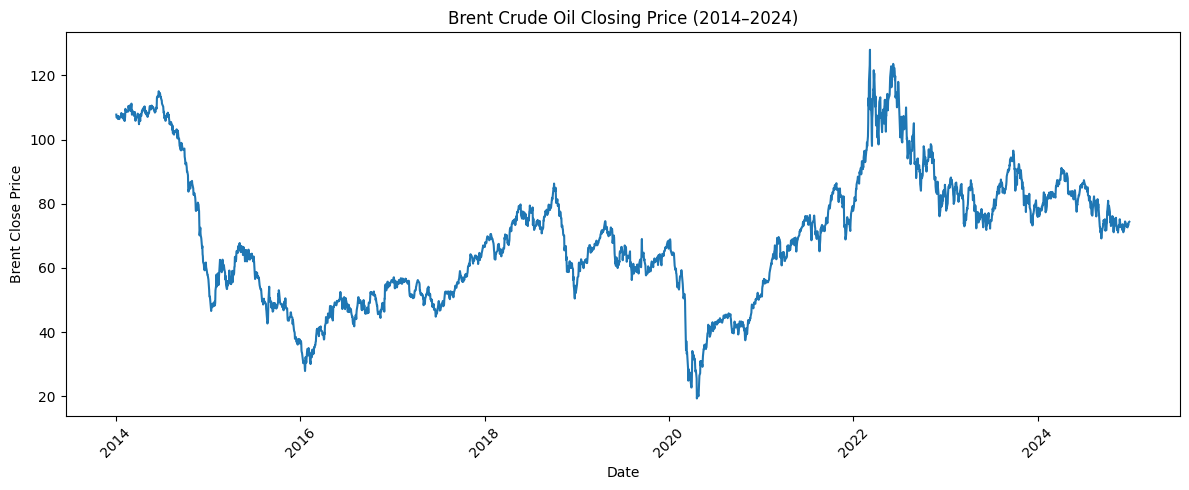

In [28]:
#Brent crude oil trend over time
plt.figure(figsize=(12, 5))
plt.plot(merged_df["Date"], merged_df["Brent_Close"])
plt.title("Brent Crude Oil Closing Price (2014–2024)")
plt.xlabel("Date")
plt.ylabel("Brent Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

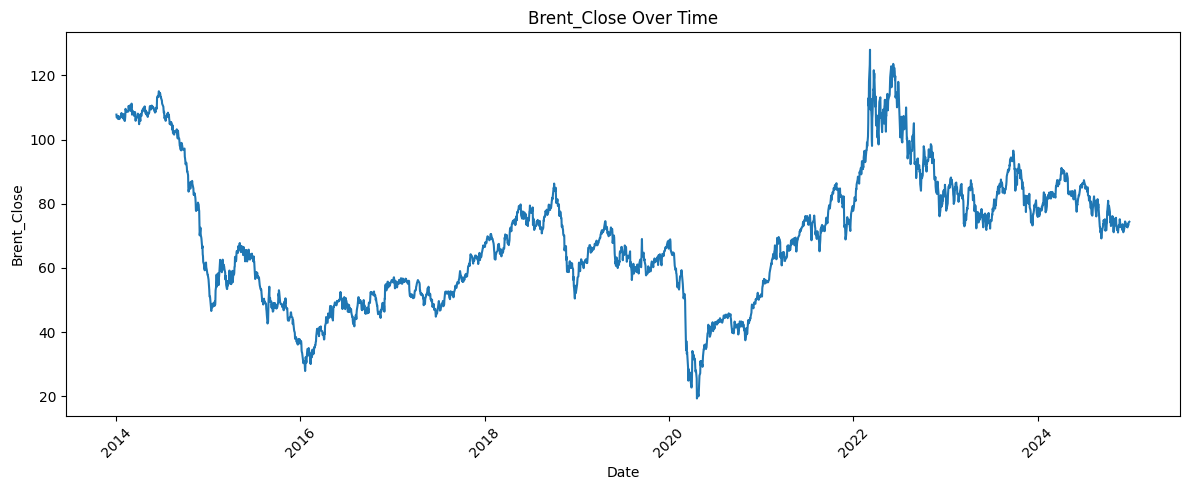

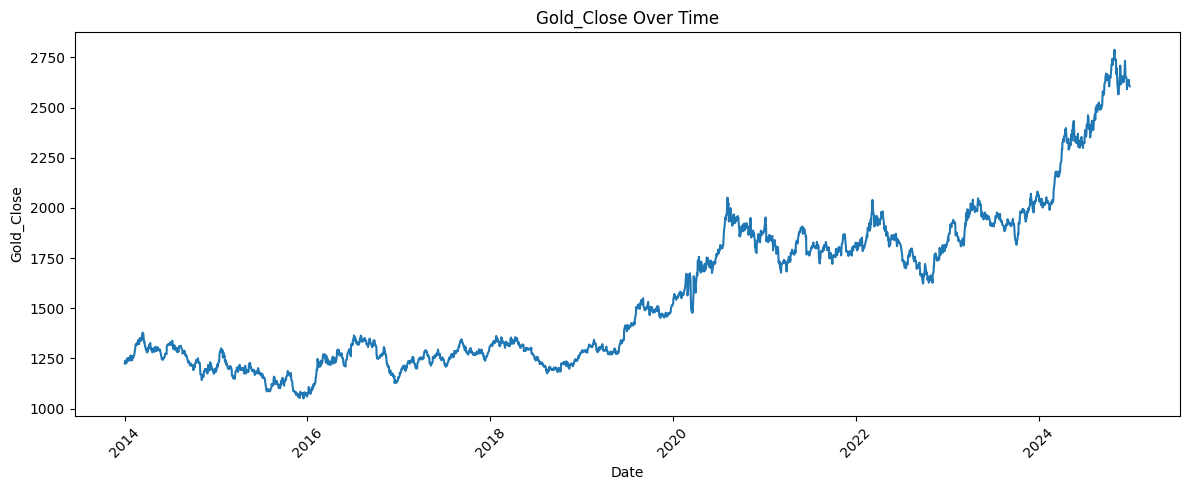

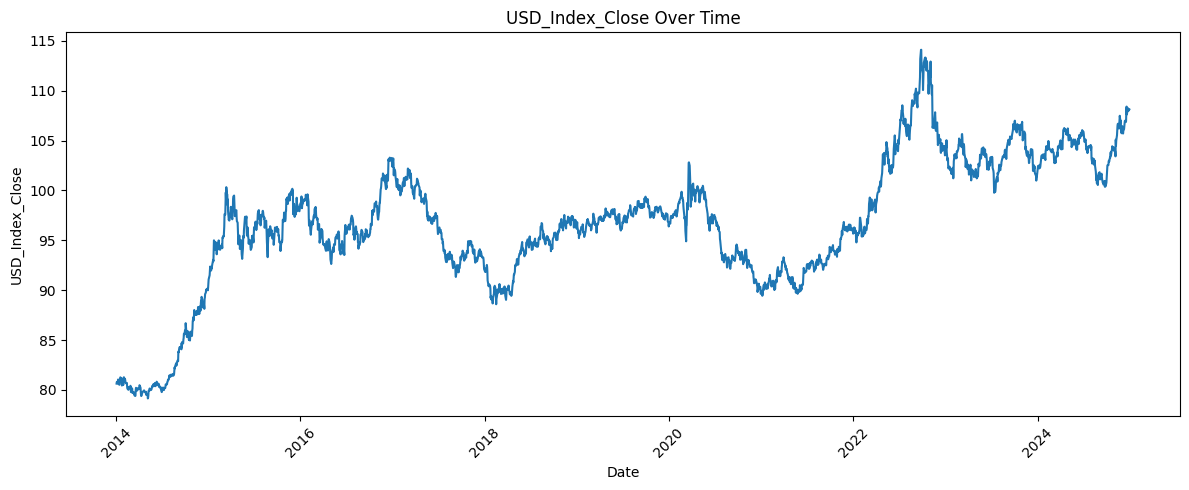

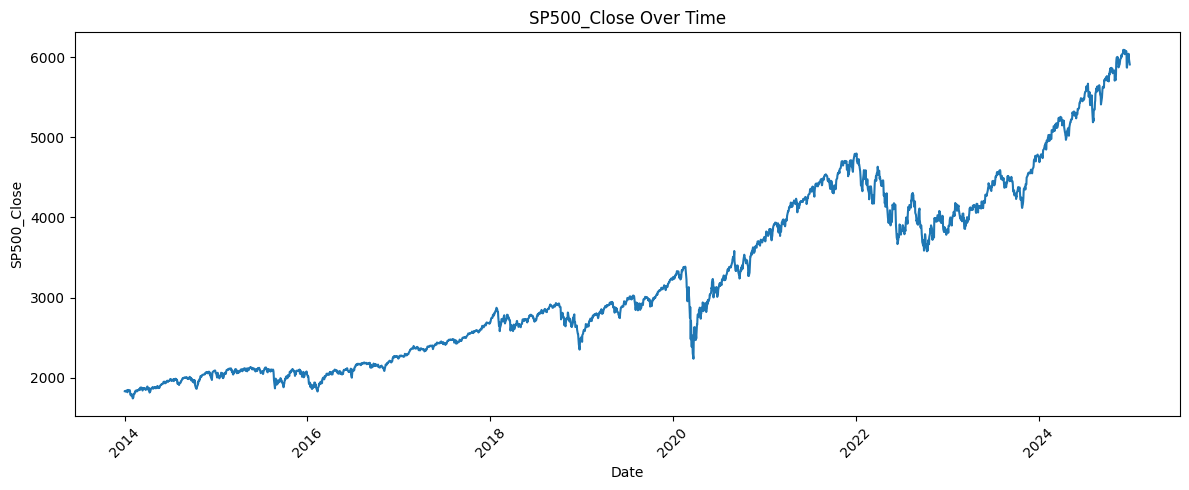

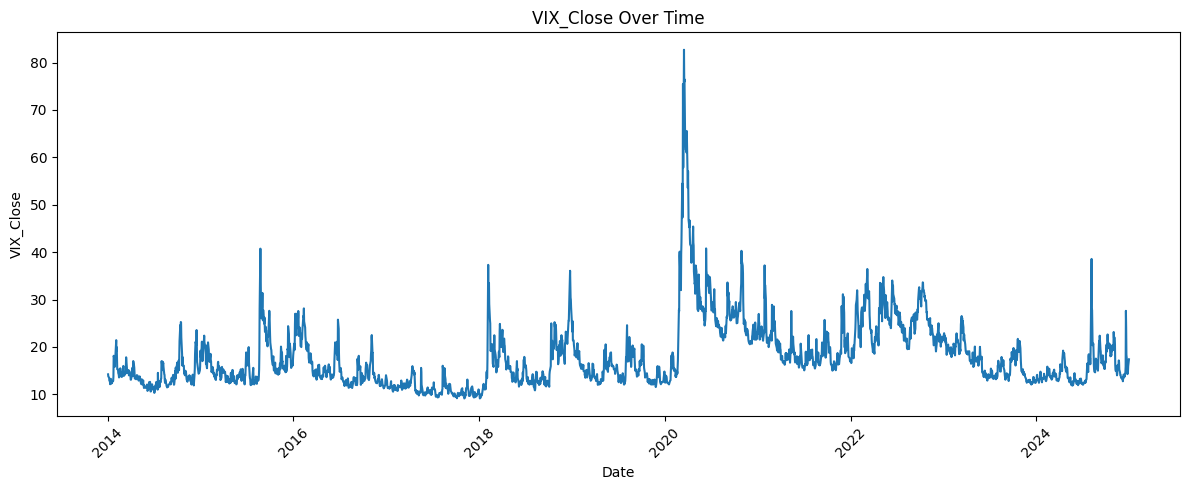

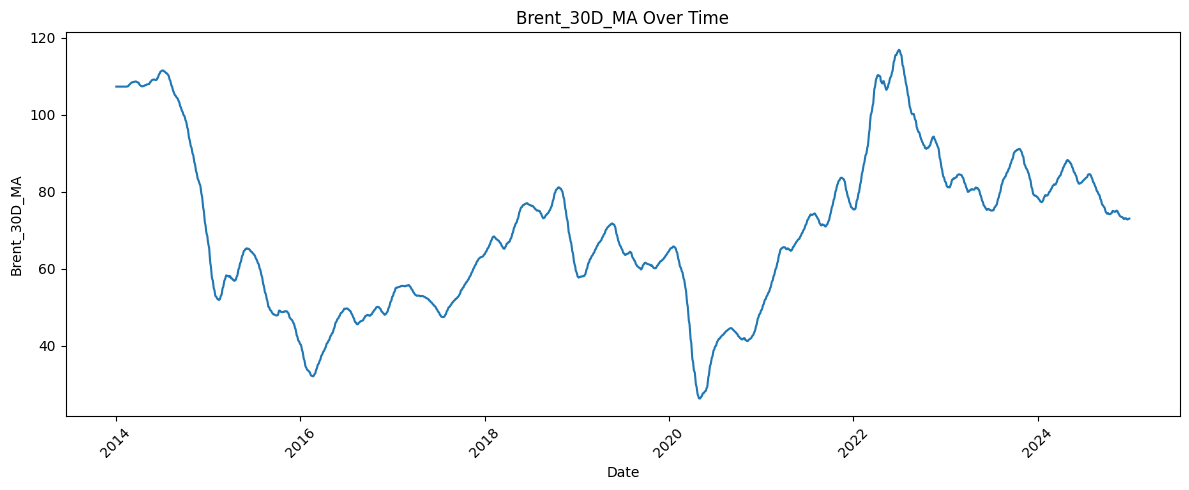

In [29]:
#Separate line charts for all variable
for col in merged_df.columns[1:]:
    plt.figure(figsize=(12, 5))
    plt.plot(merged_df["Date"], merged_df[col])
    plt.title(f"{col} Over Time")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

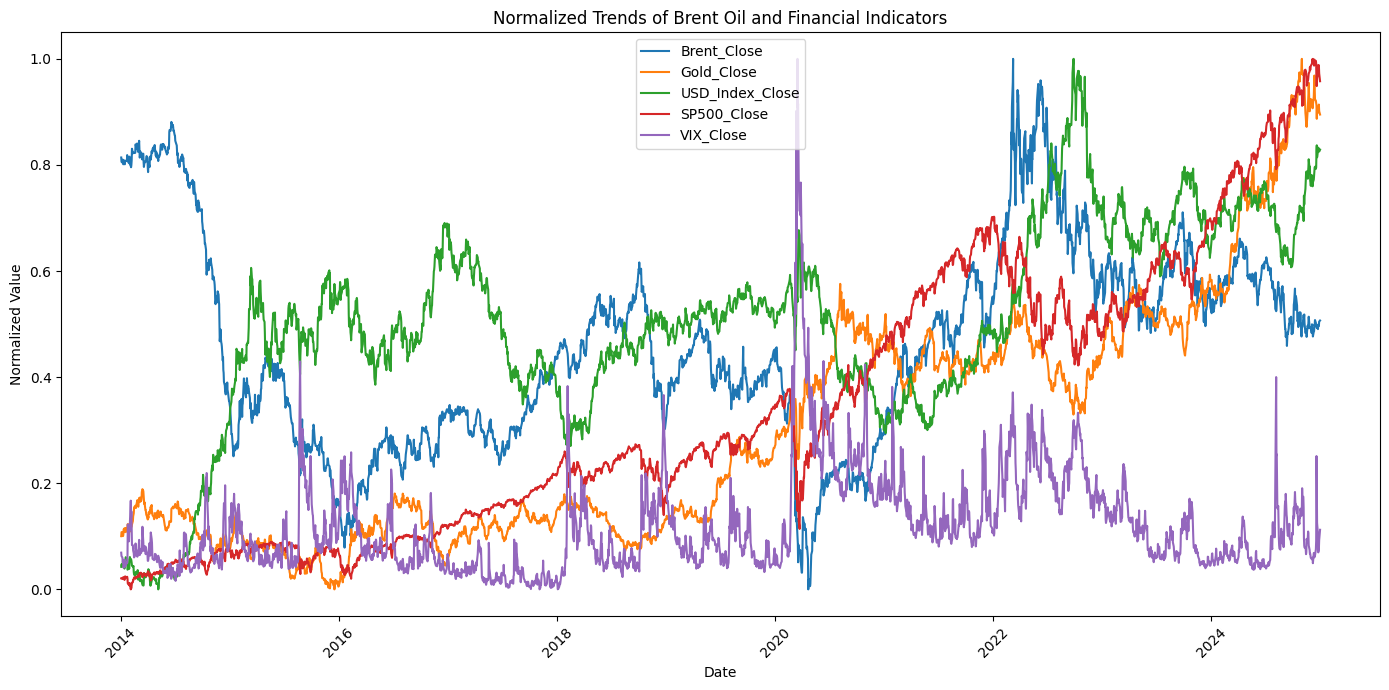

In [12]:
#Normalized multi-variable trend chart
normalized_df = merged_df.copy()

for col in normalized_df.columns[1:]:
    normalized_df[col] = (normalized_df[col] - normalized_df[col].min()) / (normalized_df[col].max() - normalized_df[col].min())

plt.figure(figsize=(14, 7))

for col in normalized_df.columns[1:]:
    plt.plot(normalized_df["Date"], normalized_df[col], label=col)

plt.title("Normalized Trends of Brent Oil and Financial Indicators")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

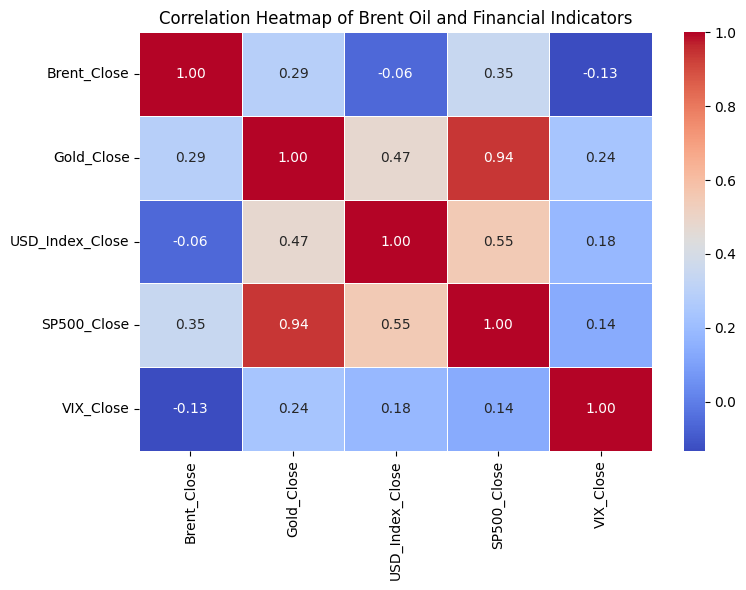

In [13]:
#Correlation heatmap using Seaborn
corr_matrix = merged_df.drop(columns=["Date"]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Brent Oil and Financial Indicators")
plt.tight_layout()
plt.show()

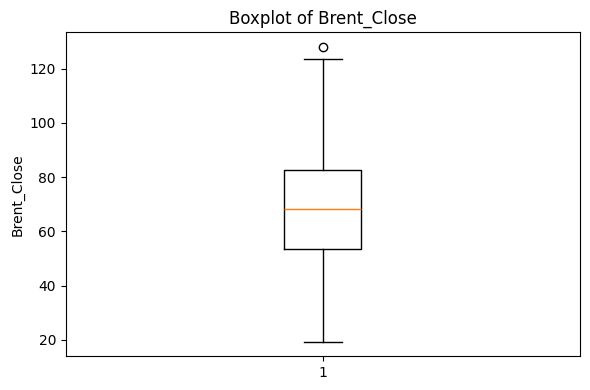

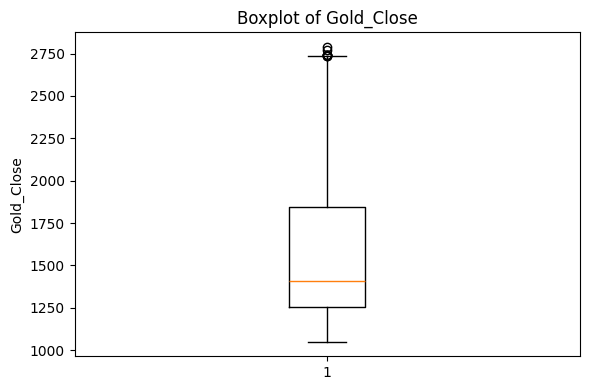

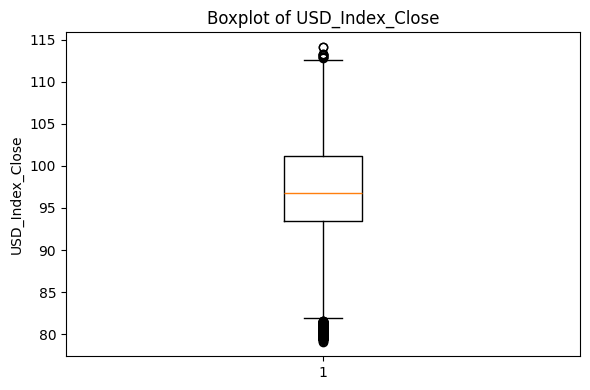

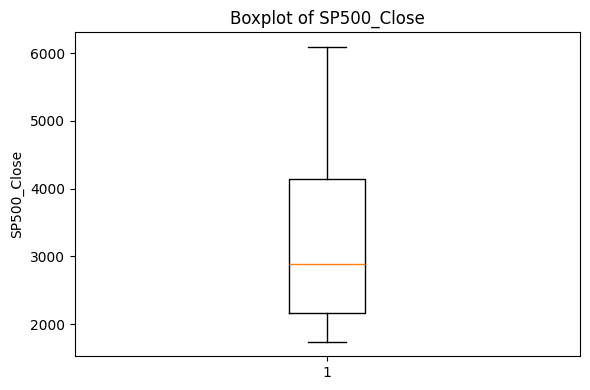

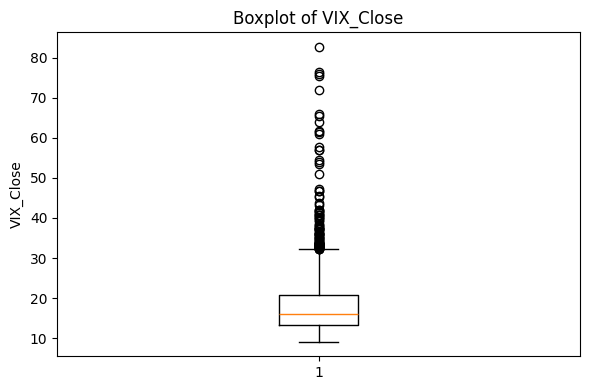

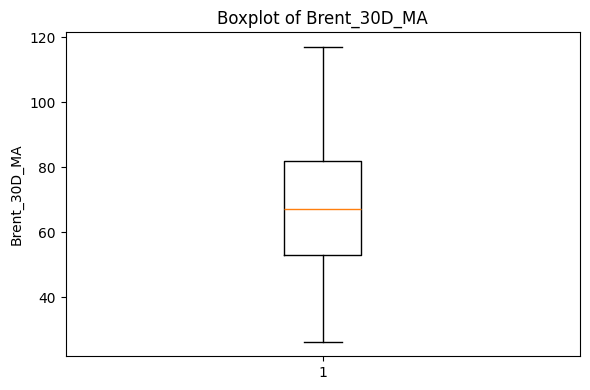

In [20]:
#Boxplot for each variable
for col in merged_df.columns[1:]:
    plt.figure(figsize=(6, 4))
    plt.boxplot(merged_df[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

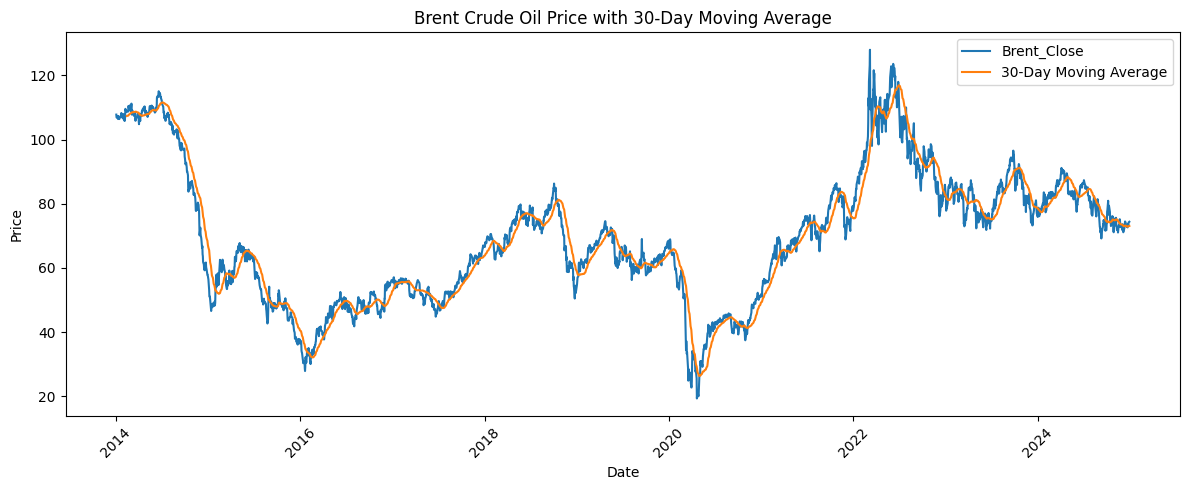

In [21]:
#Brent oil with 30-day moving average
merged_df["Brent_30D_MA"] = merged_df["Brent_Close"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(merged_df["Date"], merged_df["Brent_Close"], label="Brent_Close")
plt.plot(merged_df["Date"], merged_df["Brent_30D_MA"], label="30-Day Moving Average")
plt.title("Brent Crude Oil Price with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_148/1087285785.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = monthly_df.set_index("Date").resample("M").mean().reset_index()


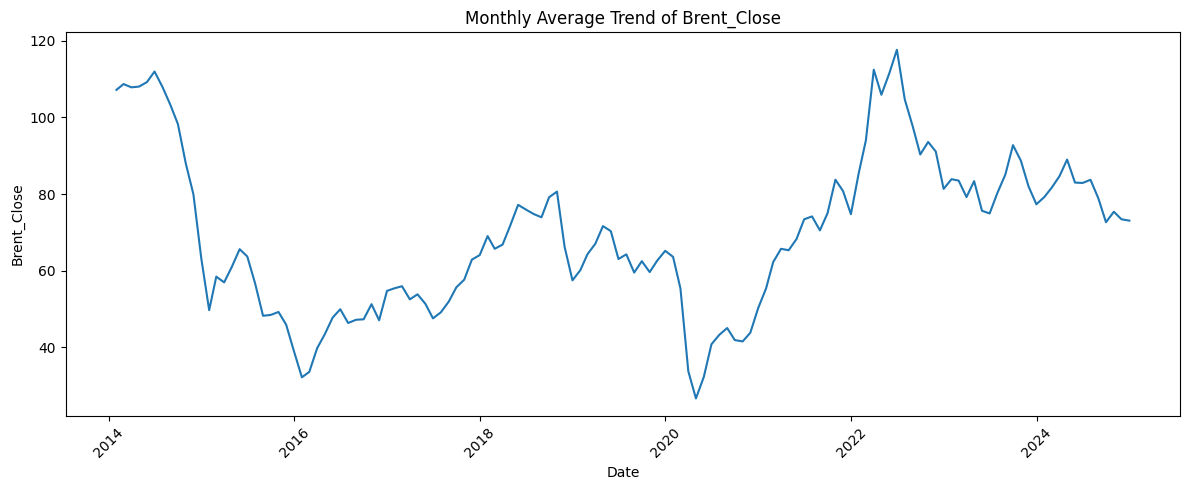

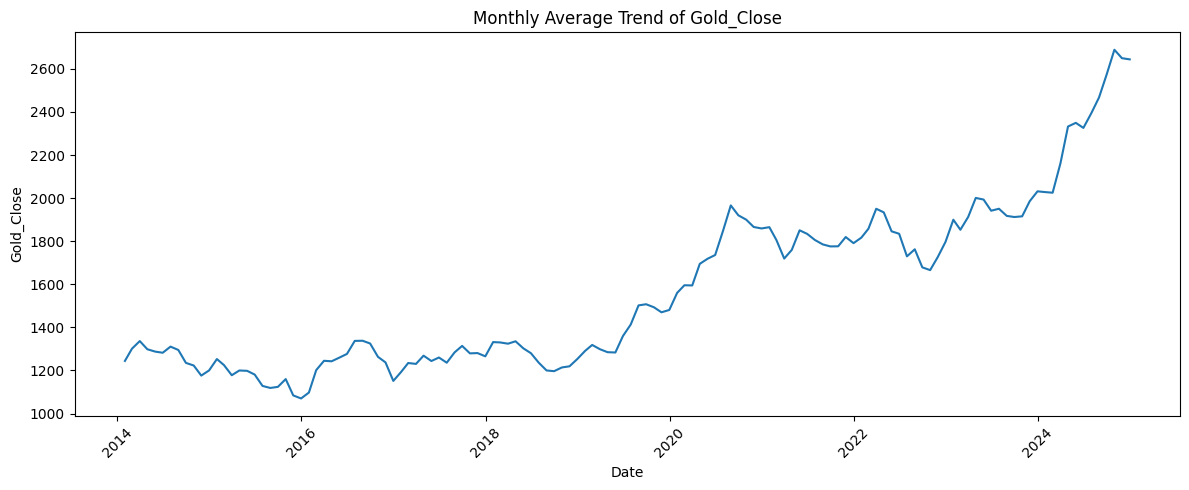

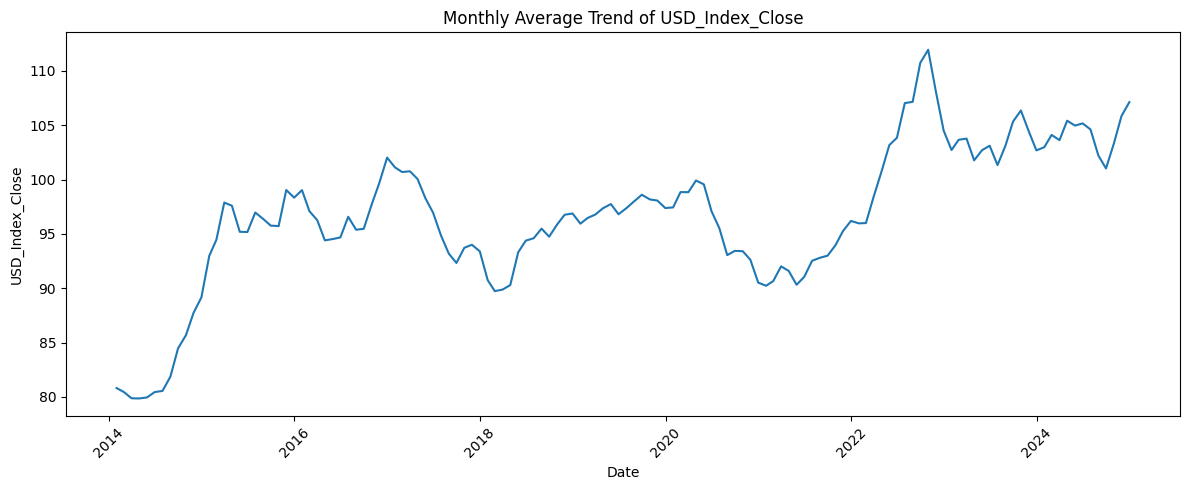

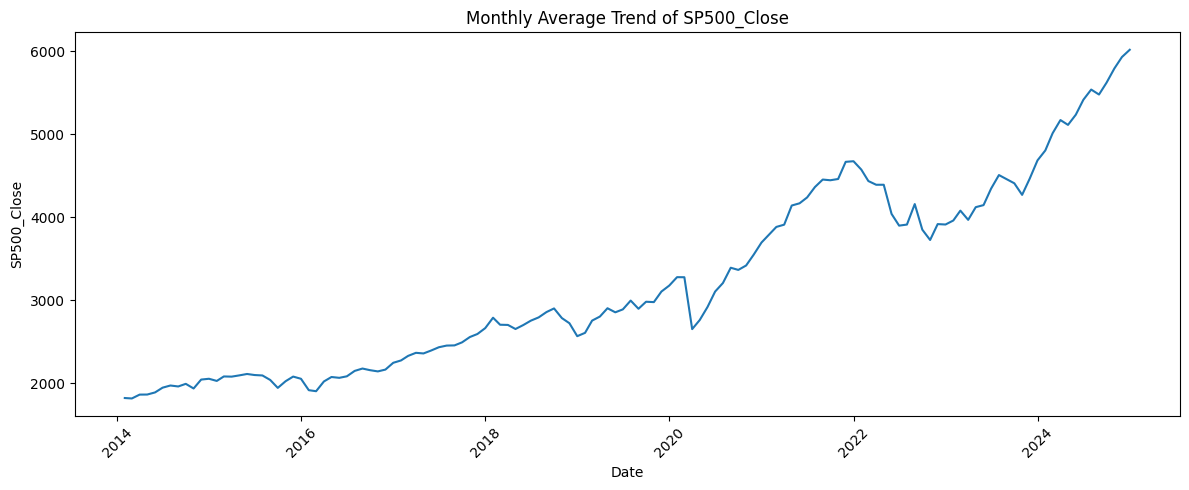

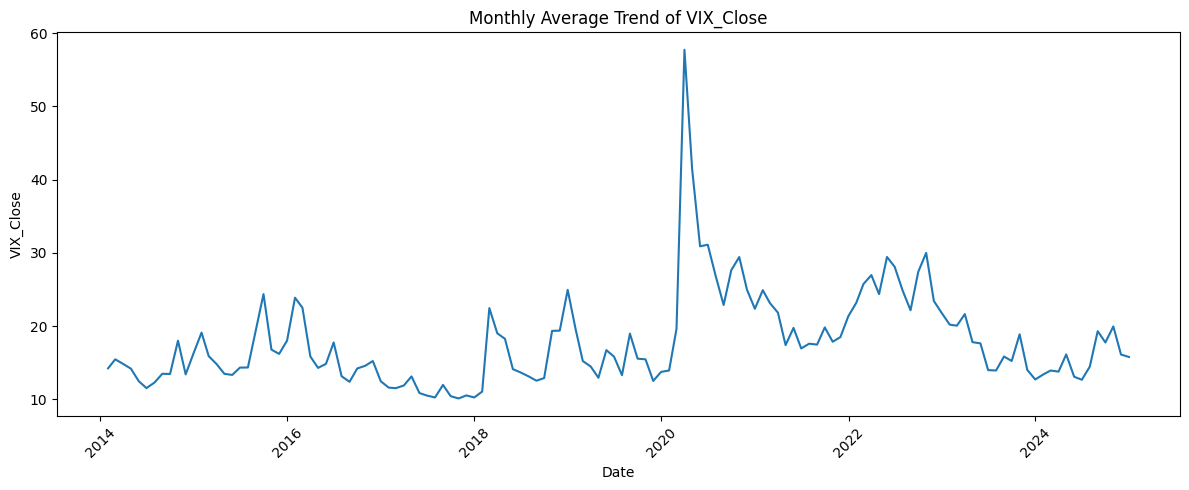

In [22]:
#Monthly average trend
monthly_df = merged_df.copy()
monthly_df = monthly_df.set_index("Date").resample("M").mean().reset_index()

for col in ["Brent_Close", "Gold_Close", "USD_Index_Close", "SP500_Close", "VIX_Close"]:
    plt.figure(figsize=(12, 5))
    plt.plot(monthly_df["Date"], monthly_df[col])
    plt.title(f"Monthly Average Trend of {col}")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [23]:
#Correlation values as a table
corr_matrix = merged_df.drop(columns=["Date", "Brent_30D_MA"]).corr()
print(corr_matrix)

                 Brent_Close  Gold_Close  USD_Index_Close  SP500_Close  \
Brent_Close         1.000000    0.290623        -0.060494     0.347547   
Gold_Close          0.290623    1.000000         0.474620     0.939469   
USD_Index_Close    -0.060494    0.474620         1.000000     0.550865   
SP500_Close         0.347547    0.939469         0.550865     1.000000   
VIX_Close          -0.133482    0.236025         0.184246     0.135951   

                 VIX_Close  
Brent_Close      -0.133482  
Gold_Close        0.236025  
USD_Index_Close   0.184246  
SP500_Close       0.135951  
VIX_Close         1.000000  


In [24]:
#Final cleaned dataset without moving average column
final_df = merged_df[["Date", "Brent_Close", "Gold_Close", "USD_Index_Close", "SP500_Close", "VIX_Close"]].copy()

final_df.to_csv("final_cleaned_dataset_for_assignment.csv", index=False)
print(final_df.head())

        Date  Brent_Close   Gold_Close  USD_Index_Close  SP500_Close  \
0 2014-01-02   107.779999  1225.000000        80.629997  1831.979980   
1 2014-01-03   106.889999  1238.400024        80.790001  1831.369995   
2 2014-01-06   106.730003  1237.800049        80.650002  1826.770020   
3 2014-01-07   107.349998  1229.400024        80.830002  1837.880005   
4 2014-01-08   107.150002  1225.300049        81.040001  1837.489990   

   VIX_Close  
0      14.23  
1      13.76  
2      13.55  
3      12.92  
4      12.87  
